## Monte Carlo Simulation — Value at Risk (VaR) | Nifty 50

Estimates 10-day, 99% VaR and Expected Shortfall for a ₹1,00,000 Nifty 50 portfolio using Monte Carlo simulation with historical bootstrapping. No normality assumption — returns are resampled directly from observed data.

### Libraries

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

### 1. Data — Asset Returns

Downloads daily close prices for asset and computes simple daily returns (Pt / Pt-1 − 1).

In [2]:
def get_returns(ticker, start):
    asset_rawdata = yf.download(tickers = ticker, 
                    start = start, 
                    auto_adjust = True)
    
    asset_close = asset_rawdata["Close"].dropna().squeeze()
    
    asset_daily_returns =  (asset_close/asset_close.shift(1)).dropna() - 1

    return asset_daily_returns

### 2. Simulation — Bootstrap Monte Carlo Paths

Resamples historical returns randomly (with replacement). Computes cumulative portfolio value paths.

In [3]:
def simulate_paths(returns, I0, sims, days, seed):
    
    days = int(days)
    
    np.random.seed(seed)
    sampled = np.random.choice(returns, size = sims*days).reshape(sims, days)

    paths = (sampled + 1).cumprod(axis = 1) * I0
    paths = np.hstack((np.ones(sims).reshape(sims, 1) * I0, paths))

    return paths

### 3. Risk Metrics — VaR & Expected Shortfall

- **VaR:** Loss at the given percentile of the terminal portfolio distribution
- **ES:** Mean loss across all paths that breach VaR — a coherent risk measure per Basel III

In [4]:
def var_es(paths, I0, confidence):
    
    final_path = paths[: , -1]
    
    prob = 1 - confidence
    
    VaR = -(np.percentile(final_path, prob*100) - I0)
    
    es = np.mean(
    final_path[final_path <= np.percentile(final_path, prob*100)]
    )
    es_loss = -(es - I0)

    return VaR, es_loss

### 4. Results

Runs the full simulation pipeline on **Nifty 50** (`^NSEI`) and prints the 10-day risk estimates for a ₹1,00,000 portfolio.

In [5]:
nifty_returns = get_returns("^NSEI", "2020-01-01")
paths = simulate_paths(nifty_returns, I0=100000, sims=10000, days=10, seed=123)
VaR, ES = var_es(paths, I0=100000, confidence=0.99)

print(f"10-Day VaR (99%): ₹{VaR:,.2f}")
print(f"10-Day ES (99%):  ₹{ES:,.2f}")

[*********************100%***********************]  1 of 1 completed

10-Day VaR (99%): ₹9,659.14
10-Day ES (99%):  ₹11,962.15


### 5. Visualisation — Simulated Portfolio Paths

100 randomly selected paths over the given horizon.

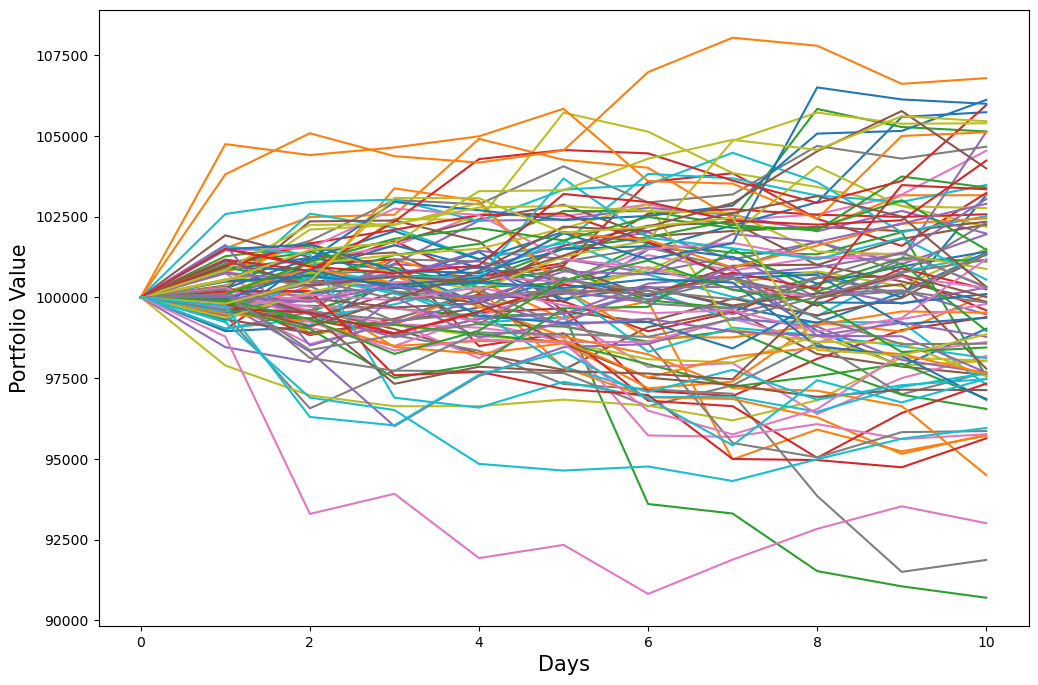

In [6]:
plt.figure(figsize = (12, 8))
plt.plot(paths[ : 100].T)
plt.xlabel("Days", fontsize = 15)
plt.ylabel("Portfolio Value", fontsize = 15)
plt.show()

#### **Prepared by:** Yusuf Sayeed | FRM Part 1 Cleared | FMVA